In [1]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)


import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import torch.nn as nn
import torch
import random
from tqdm.autonotebook import tqdm
import seaborn as sns
from envs import NonStationaryEnv
from basal_ganglia import train
import pickle

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_11396/2656916288.py:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


In [ ]:
# SEED = 10

# # Python
# random.seed(SEED)
# # NumPy
# np.random.seed(SEED)
# # PyTorch
# torch.manual_seed(SEED)


## Hyper Params

In [ ]:
TRAILS = 150
EPOCHS = 100
BINS = 15
LR = 0.1 
NUM_ARMS = 3
SCALING_FACTOR = 100
TIME_STAMP_CHANGE = 75
BIN_SIZE = TRAILS//BINS
BIN_CHANGE = TIME_STAMP_CHANGE // BIN_SIZE

## TRAINING LOOP

In [4]:
env = NonStationaryEnv(
    num_arms = NUM_ARMS, 
    mean_reward = np.array([20,40,30])/SCALING_FACTOR, 
    std = np.array([5,5,5])/SCALING_FACTOR, 
    mean_rew_change = np.array([10,35,40])/SCALING_FACTOR, 
    std_change = np.array([5,5,5])/SCALING_FACTOR, 
    time_stamp_change = TIME_STAMP_CHANGE)

BEST_ARM_BEFORE = 1
BEST_ARM_AFTER = 2

BEST_ARM = torch.zeros((EPOCHS,TRAILS), dtype=int)
BEST_ARM[:,:TIME_STAMP_CHANGE] = BEST_ARM_BEFORE
BEST_ARM[:,TIME_STAMP_CHANGE:] = BEST_ARM_AFTER  

In [ ]:
reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor= train(env, 
                                                      trails = TRAILS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data ='rossler',
                                                      d1_amp=0.7,
                                                      d2_amp=0.05, 
                                                      gpi_threshold=0.3,
                                                      max_gpi_iters=50,
                                                      del_lim=None, train_IP = False, 
                                                      del_med = None, printing = True,
                                                      gpi_mean= 1, ep_0 = 0.3,
                                                      alpha_ep = 0.2,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0)

## ANALYSIS

In [6]:
mean_picks = {key: torch.mean(avg_counts[key], dim = 0) for key in list(avg_counts.keys())}
IP_avg = {key: torch.mean(ip_monitor[key], dim =0).detach().numpy() for key in list(ip_monitor.keys())}
DP_avg = {key: torch.mean(dp_monitor[key], dim =0).detach().numpy() for key in list(dp_monitor.keys())}
IP_var = np.std(np.stack(list(IP_avg.values()), axis=0),axis = 0)[:,0]
arm_chosen_monitor = arm_chosen_monitor.to(torch.int)
# Computing Accuracy
accuracy_percentages = torch.zeros((EPOCHS, BINS))

for i in range(BINS):
    start, end = i * BIN_SIZE, (i + 1) * BIN_SIZE
    correct_choices = torch.sum(arm_chosen_monitor[:, start:end] == BEST_ARM[:,start:end], axis = 1)
    accuracy_percentages[:, i] = (correct_choices / BIN_SIZE) * 100

accuracy_per_bin = torch.mean(accuracy_percentages,axis = 0)

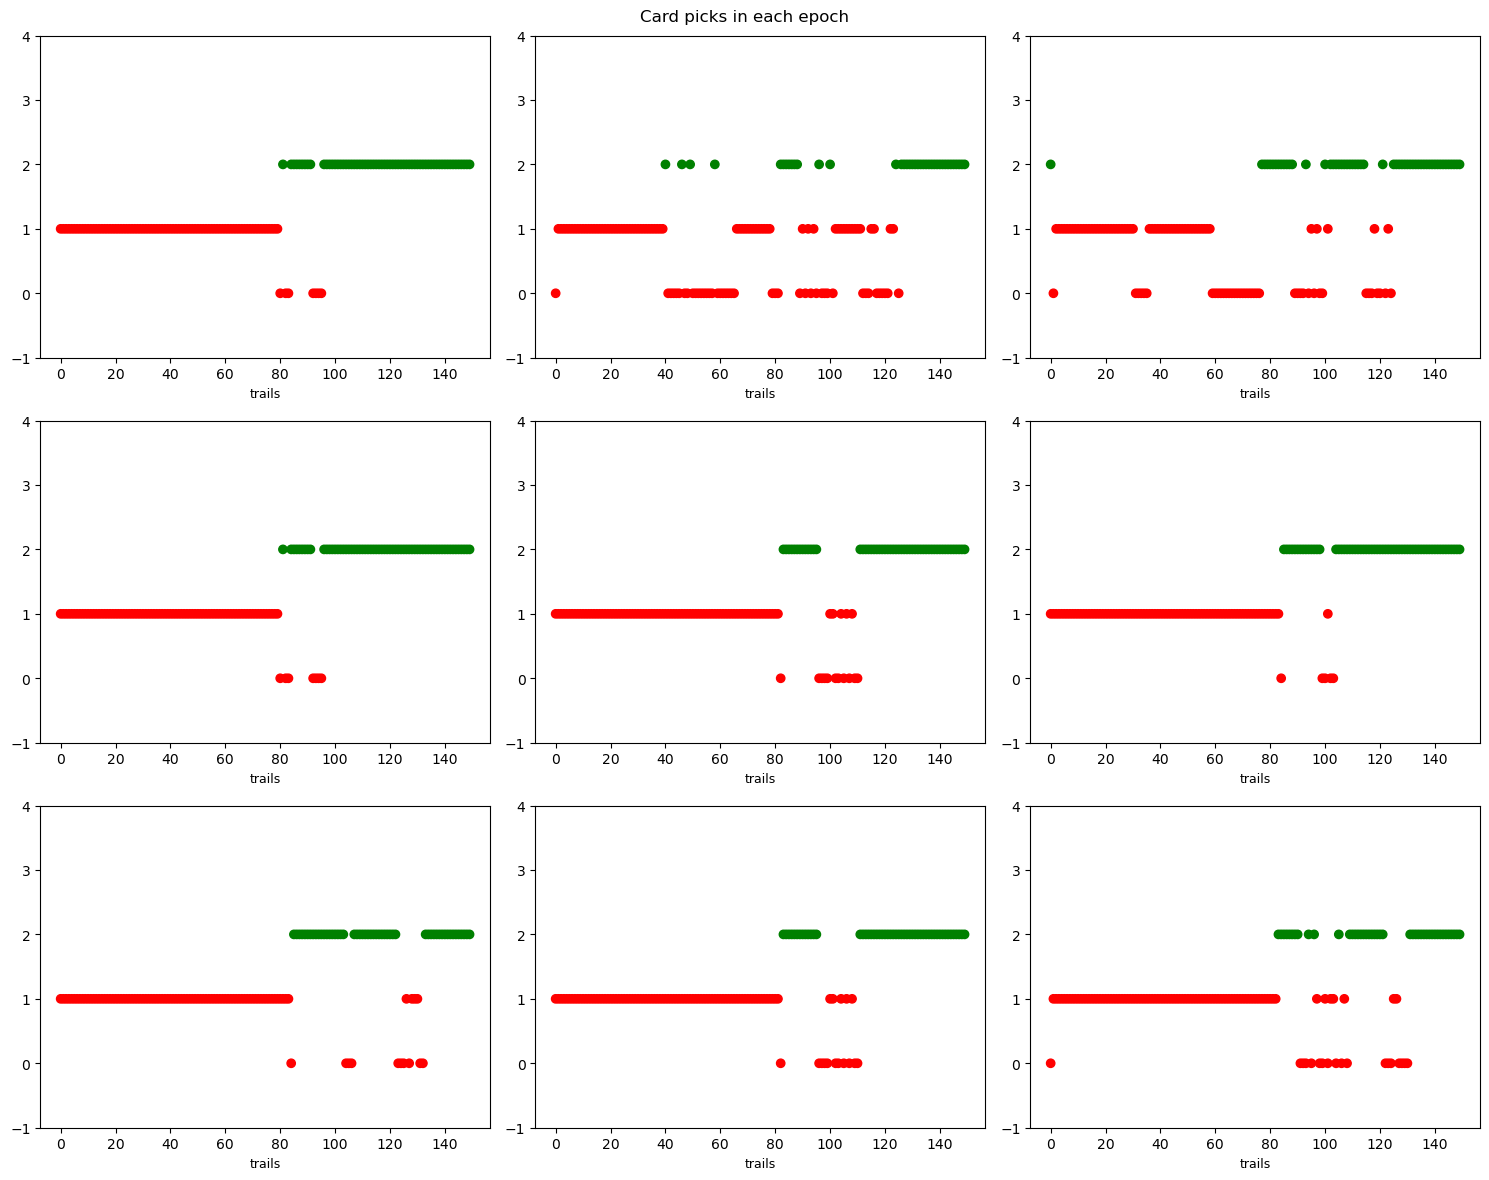

In [7]:
random_epochs = np.random.choice(np.arange(EPOCHS), size = 9)
i = 1
plt.figure(figsize=(15,12))
for e in random_epochs:
    plt.subplot(3,3,i)
    colors = np.where(np.isin(arm_chosen_monitor[e],[0,1]), 'r', 'g')
    plt.scatter(np.arange(TRAILS), arm_chosen_monitor[e], c = colors)
    plt.ylim(-1,4)
    plt.xlabel('trails', fontsize = 9)
    i+=1

plt.suptitle('Card picks in each epoch')
plt.tight_layout()

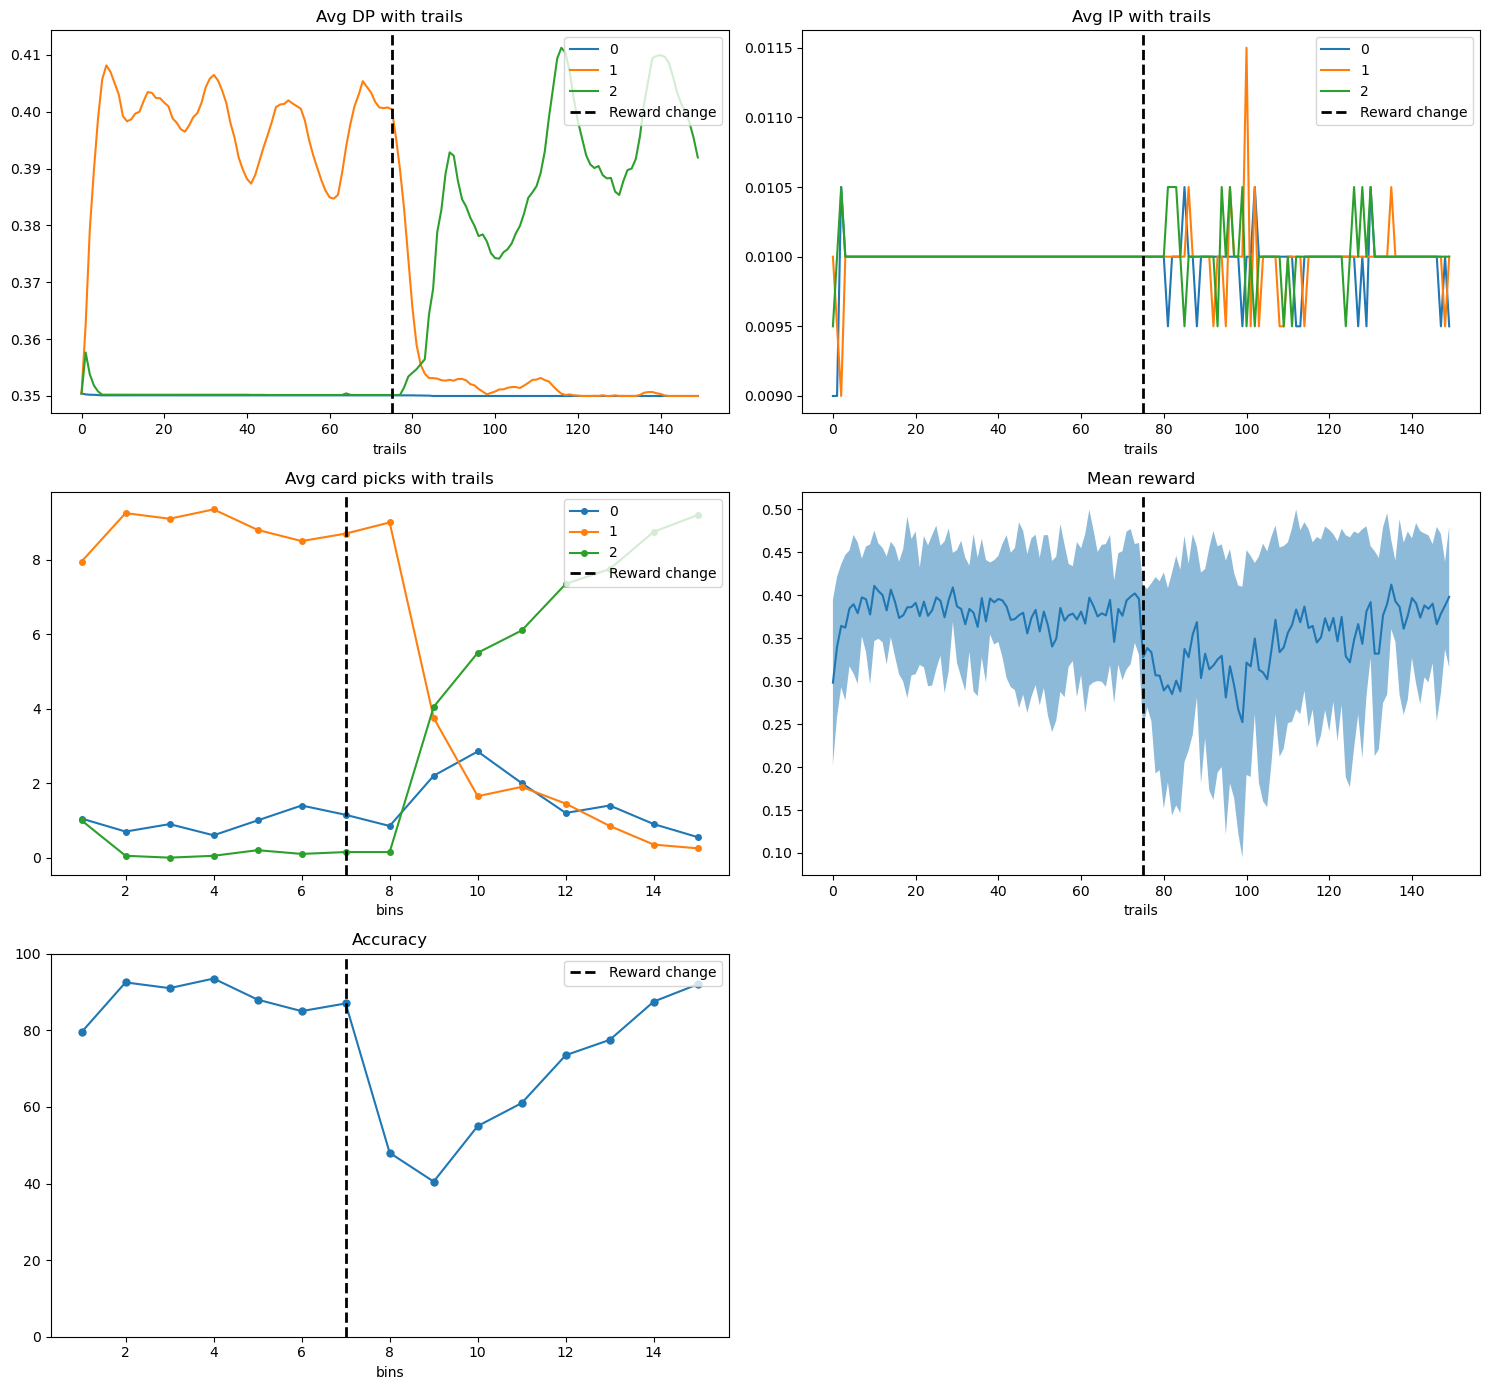

In [8]:
BIN = np.arange(BINS)+1
color_map = ['r', 'r', 'g', 'g']
plt.figure(figsize=(15,14))
plt.subplot(321)
for i in DP_avg.keys():
    plt.plot(np.arange(TRAILS), DP_avg[i], label = i)
plt.axvline(x=TIME_STAMP_CHANGE, color='black', linestyle='--', linewidth=2, label='Reward change')
plt.xlabel('trails')
plt.title('Avg DP with trails')
plt.legend(loc = 'upper right')

plt.subplot(322)
for i in DP_avg.keys():
    plt.plot(np.arange(TRAILS), IP_avg[i], label = i)
plt.axvline(x=TIME_STAMP_CHANGE, color='black', linestyle='--', linewidth=2, label='Reward change')
plt.xlabel('trails')
plt.title('Avg IP with trails')
plt.legend(loc = 'upper right')

plt.subplot(323)
for i in mean_picks.keys():
    plt.plot(BIN,mean_picks[i], label = i, marker = '.', markersize = 8)
plt.axvline(x=BIN_CHANGE, color='black', linestyle='--', linewidth=2, label='Reward change')
plt.title('Avg card picks with trails')
plt.xlabel('bins')
plt.legend(loc = 'upper right')


plt.subplot(324)
mean_rew = torch.mean(reward_monitor, 0)
std_rew = torch.std(reward_monitor,0)
plt.plot(np.arange(TRAILS), mean_rew)
plt.fill_between(np.arange(TRAILS), mean_rew - std_rew, mean_rew+std_rew, alpha = 0.5)
plt.axvline(x=TIME_STAMP_CHANGE, color='black', linestyle='--', linewidth=2, label='Reward change')
plt.title('Mean reward')
plt.xlabel('trails')

# plt.subplot(325)
# plt.plot(IP_var)
# plt.title('IP variance')
# plt.xlabel('trails')

plt.subplot(325)
plt.plot(BIN, accuracy_per_bin, marker = '.', markersize = 10)
plt.axvline(x=BIN_CHANGE, color='black', linestyle='--', linewidth=2, label='Reward change')
plt.title('Accuracy')
plt.ylim(0,100)
plt.xlabel('bins')
plt.legend(loc = 'upper right')
plt.tight_layout()

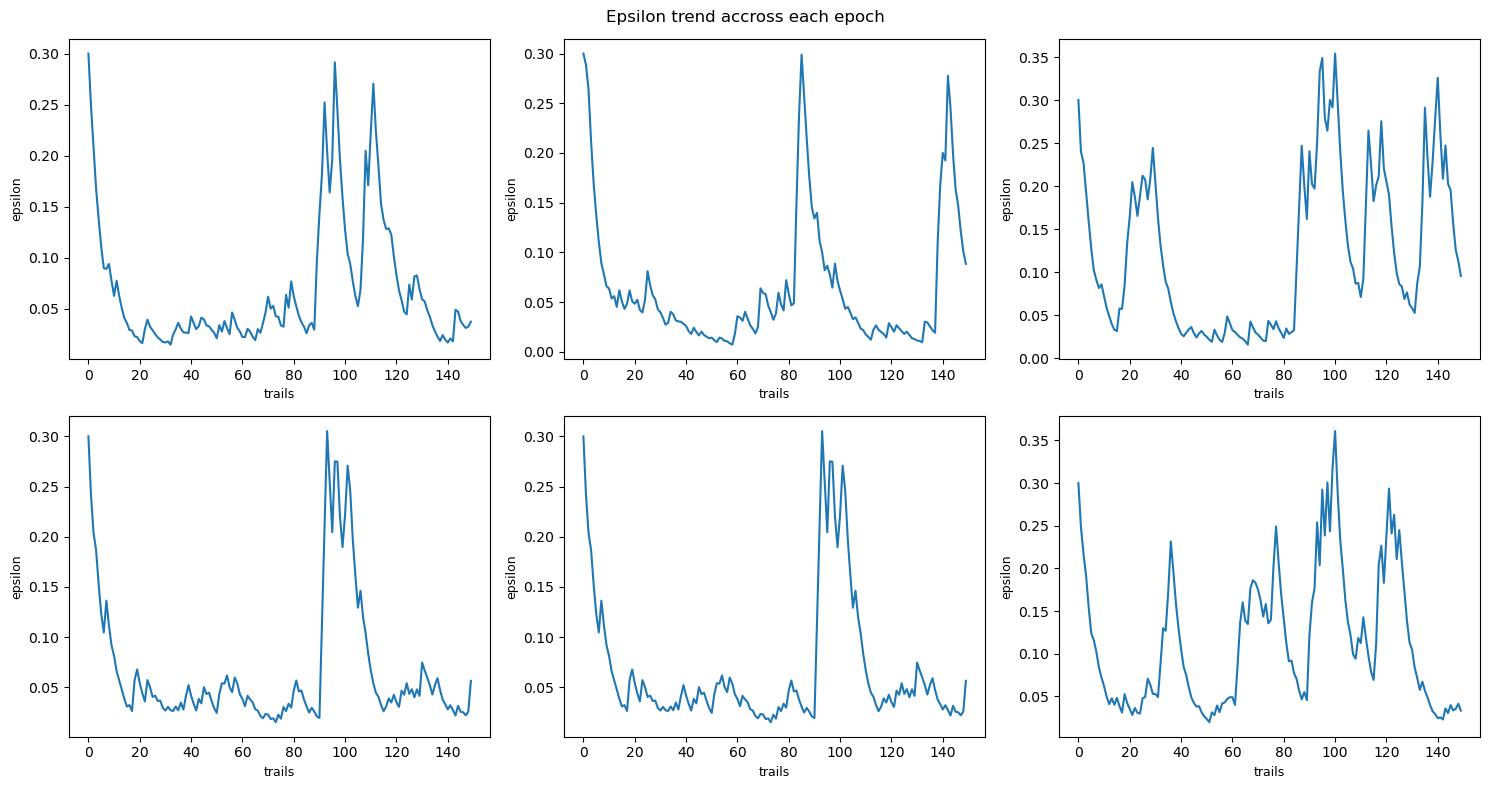

In [9]:
random_epochs = np.random.choice(np.arange(EPOCHS), size = 6)
i = 1
plt.figure(figsize=(15,8))
for e in random_epochs:
    plt.subplot(2,3,i)
    plt.plot(np.arange(TRAILS), ep_monitor[e])
    i+=1
    plt.xlabel('trails', fontsize = 9)
    plt.ylabel('epsilon', fontsize = 9)

plt.suptitle('Epsilon trend accross each epoch')
plt.tight_layout()

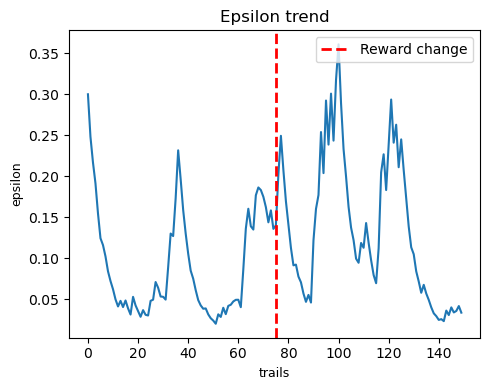

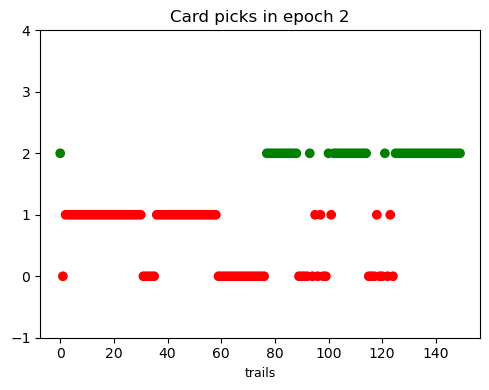

In [10]:
plt.figure(figsize=(5,4))
plt.plot(np.arange(TRAILS), ep_monitor[2])
plt.axvline(x=TIME_STAMP_CHANGE, color='red', linestyle='--', linewidth=2, label='Reward change')
plt.xlabel('trails', fontsize = 9)
plt.ylabel('epsilon', fontsize = 9)
plt.legend(loc = 'upper right')
plt.title('Epsilon trend')
plt.tight_layout()
plt.figure(figsize=(5,4))
colors = np.where(np.isin(arm_chosen_monitor[2],[0,1]), 'r', 'g')
plt.scatter(np.arange(TRAILS), arm_chosen_monitor[2], c = colors)
plt.ylim(-1,4)
plt.xlabel('trails', fontsize = 9)
plt.title('Card picks in epoch 2')
plt.tight_layout()


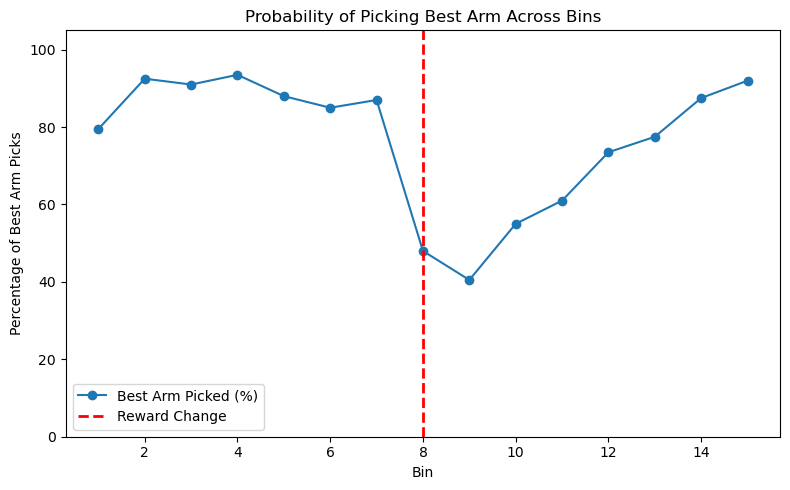

In [11]:
# Plot: Probability/Percentage of Picking the Best Arm Across Bins
plt.figure(figsize=(8,5))
plt.plot(BIN, accuracy_per_bin, marker='o', label='Best Arm Picked (%)')
plt.axvline(BIN_CHANGE+1, color='red', linestyle='--', linewidth=2, label='Reward Change')
plt.xlabel('Bin')
plt.ylabel('Percentage of Best Arm Picks')
plt.title('Probability of Picking Best Arm Across Bins')
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
accuracy_per_bin

tensor([79.5000, 92.5000, 91.0000, 93.5000, 88.0000, 85.0000, 87.0000, 48.0000,
        40.5000, 55.0000, 61.0000, 73.5000, 77.5000, 87.5000, 92.0000])

In [13]:
# # saving pickle data
# data = {'accuracy': accuracy_percentages.numpy(),
#         'reward_monitor': reward_monitor.numpy(),
#         'epsilon_monitor': ep_monitor.numpy(),
#         'arm_chosen_monitor': arm_chosen_monitor.numpy()
#         }

# with open('non_stationary_bandit_data_normal_1.pkl', 'wb') as f:
#     pickle.dump(data, f)